In [2]:
import warnings
warnings.filterwarnings("ignore")

from datetime import date, timedelta
from pypfopt import expected_returns
import pyfolio as pf
import ffn
#import qgrid

from empyrical.stats import  *

# 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


import quandl
quandl.ApiConfig.api_key = 'fhbmNKX6oNP7PpFuZJNo'

import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'retina'
%matplotlib inline

In [3]:
cd /Users/safishajjouz/GitHub/myPythonPackages

/Users/safishajjouz/GitHub/myPythonPackages


In [4]:
from myPortfolioManagement.myData import * 
from myPortfolioManagement.myPerformanceAnalytics import *

In [5]:
# Set dates 
start_date = '1993-01-01'
date_end = date.today()
date_end = date_end.strftime("%Y-%m-%d")

### Get S&P 500 Stock Prices 
(To do: make this process automatic in the myData Module)

In [6]:
# import stock prices 
df = pd.read_csv('/Users/safishajjouz/Dropbox/Schonfeld_shared_folder/sp_prices.csv')

In [7]:
df = df[['ref.date', 'ticker', 'price.adjusted']]
df = df.rename(columns = {'ref.date': 'Date', 'price.adjusted':'prices'})
df['Date'] = pd.to_datetime(df['Date'],format='%Y-%m-%d')
df = df.set_index('Date')

In [8]:
# from long to wide 
df_cleaned = df.pivot_table(index='Date', 
                        columns='ticker', 
                        values='prices')

In [9]:
df_bench = get_stock_prices(yahoo_tickers = ['^GSPC'], 
                 start_date = start_date,
                 end_date = date_end, 
                 time_interval = 'daily', 
                 num_cpus = 5) 

df_sp500 = df_bench.pivot_table(index='Date', 
                        columns='yahoo_ticker', 
                        values='close')

get_stock_prices took 7.486sec


In [10]:
df_cleaned = df_cleaned.reset_index().merge(df_sp500.reset_index())

In [11]:
df_cleaned = df_cleaned.set_index('Date')

In [12]:
#simple returns 
from pypfopt.expected_returns import *
ret_simple = returns_from_prices(df_cleaned)
ret_simple

,A,AAL,AAP,AAPL,ABBV,ABC,ABMD,ABT,ACN,ADBE,...,XLNX,XOM,XRAY,XYL,YUM,ZBH,ZBRA,ZION,ZTS,^GSPC
Date,,,,,,,,,,,,,,,,,,,,,
1993-01-05,0.000000,0.000000,0.000000,0.017168,0.000000,0.000000,-0.044444,-0.020576,0.000000,0.015038,...,-0.010417,0.010184,-0.012626,0.000000,0.000000,0.000000,0.005263,0.009868,0.000000,-0.002389
1993-01-06,0.000000,0.000000,0.000000,0.042194,0.000000,0.000000,0.000000,-0.025210,0.000000,-0.007407,...,0.084210,-0.004033,-0.017903,0.000000,0.000000,0.000000,0.010471,-0.003258,0.000000,0.000414
1993-01-07,0.000000,0.000000,0.000000,-0.012146,0.000000,0.000000,0.023256,-0.021551,0.000000,-0.022388,...,-0.048543,-0.002024,-0.020833,0.000000,0.000000,0.000000,-0.025907,0.006536,0.000000,-0.008722
1993-01-08,0.000000,0.000000,0.000000,0.020493,0.000000,0.000000,-0.068182,0.017620,0.000000,0.015267,...,-0.030612,-0.016227,-0.037234,0.000000,0.000000,0.000000,0.000000,-0.021104,0.000000,-0.003900
1993-01-11,0.000000,0.000000,0.000000,0.030120,0.000000,0.000000,-0.060976,-0.003481,0.000000,0.022556,...,0.031579,-0.002062,0.024862,0.000000,0.000000,0.000000,-0.021277,0.014925,0.000000,0.004428
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-01-03,-0.018565,0.043987,-0.012923,0.025004,0.000148,-0.002032,0.019823,-0.012079,-0.017706,-0.004744,...,0.043579,0.038405,0.019717,-0.025267,-0.016780,0.016452,-0.018985,0.017099,-0.040979,0.006374
2022-01-04,-0.033806,0.014400,0.001140,-0.012692,-0.001920,-0.009501,-0.012831,-0.023518,-0.007146,-0.018374,...,-0.028834,0.037614,0.005098,0.010608,0.005347,0.010145,0.006337,0.028487,-0.038072,-0.000630
2022-01-05,-0.017131,-0.017876,-0.002531,-0.026600,0.005253,0.008678,-0.064686,-0.004493,-0.017611,-0.071426,...,-0.061566,0.012437,-0.016090,-0.013629,-0.012677,-0.003297,-0.050068,0.002270,-0.038024,-0.019393


In [13]:
# check some basic perfomance stats for each asset 

## Consider scaling this using Ray 

columns = ret_simple.columns.to_list()
df_stats = []
for col in columns:
    ret_temp = ret_simple[[col]].dropna()
    price_index = ffn.core.to_price_index(ret_temp, start=100)
    df_stats_temp = ffn.core.GroupStats(price_index).stats
    df_stats_temp = df_stats_temp.transpose()
    df_stats.append(df_stats_temp)

In [32]:
basics = ['start', 'end', 'total_return', 'cagr', 'yearly_mean','yearly_vol', 'max_drawdown']
df_perf = pd.concat(df_stats)[basics]
df_perf = df_perf[['yearly_mean', 'yearly_vol']]
df_perf

,yearly_mean,yearly_vol
A,0.116637,0.352283
AAL,0.116152,0.541155
AAP,0.135179,0.268039
AAPL,0.441727,0.730744
ABBV,0.072217,0.169263
...,...,...
ZBH,0.077498,0.230823
ZBRA,0.195104,0.369933
ZION,0.160039,0.415564
ZTS,0.081008,0.162989


In [33]:
df_greeks = alpha_beta_table(ret_simple.drop('^GSPC', axis=1), returns_benchmark = ret_simple['^GSPC'], my_date_col_name = None,
               my_assets_col_name = 'stock', rf = 0.02, 
               period = 'daily')

In [34]:
df_perf = df_perf.reset_index().rename(columns = {'index':'stock'})
df_greeks = df_greeks.reset_index().rename(columns = {'fund':'stock'})

In [30]:
df_stocks

,stock,stock,yearly_mean,yearly_vol
0,0,A,0.116637,0.352283
1,1,AAL,0.116152,0.541155
2,2,AAP,0.135179,0.268039
3,3,AAPL,0.441727,0.730744
4,4,ABBV,0.072217,0.169263
...,...,...,...,...
492,492,ZBH,0.077498,0.230823
493,493,ZBRA,0.195104,0.369933
494,494,ZION,0.160039,0.415564
495,495,ZTS,0.081008,0.162989


In [35]:
df_stocks = df_greeks.merge(df_perf)
df_stocks

,stock,alpha,alpha_bull,alpha_bear,beta,beta_bull,beta_bear,yearly_mean,yearly_vol
0,A,0.32,0.26,-0.35,1.04,0.99,0.96,0.116637,0.352283
1,AAL,4.92,4.21,1.50,1.34,1.28,1.26,0.116152,0.541155
2,AAP,-0.34,-0.47,0.54,0.90,0.88,1.01,0.135179,0.268039
3,AAPL,1.60,1.60,1.12,1.14,1.17,1.12,0.441727,0.730744
4,ABBV,-0.45,-0.55,-0.40,0.87,0.78,0.89,0.072217,0.169263
...,...,...,...,...,...,...,...,...,...
491,YUM,-0.41,-0.43,-0.36,0.87,0.89,0.89,0.149916,0.215735
492,ZBH,-0.24,-0.49,-0.18,0.94,0.82,0.97,0.077498,0.230823
493,ZBRA,3.07,2.66,2.36,1.24,1.19,1.23,0.195104,0.369933
494,ZION,1.23,0.45,1.23,1.13,1.01,1.17,0.160039,0.415564


In [36]:
X = df_stocks[['stock', 'yearly_vol']]
X = X.set_index('stock')

In [37]:
# Standardising the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
# Transformed the arrays of scaled values into a DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

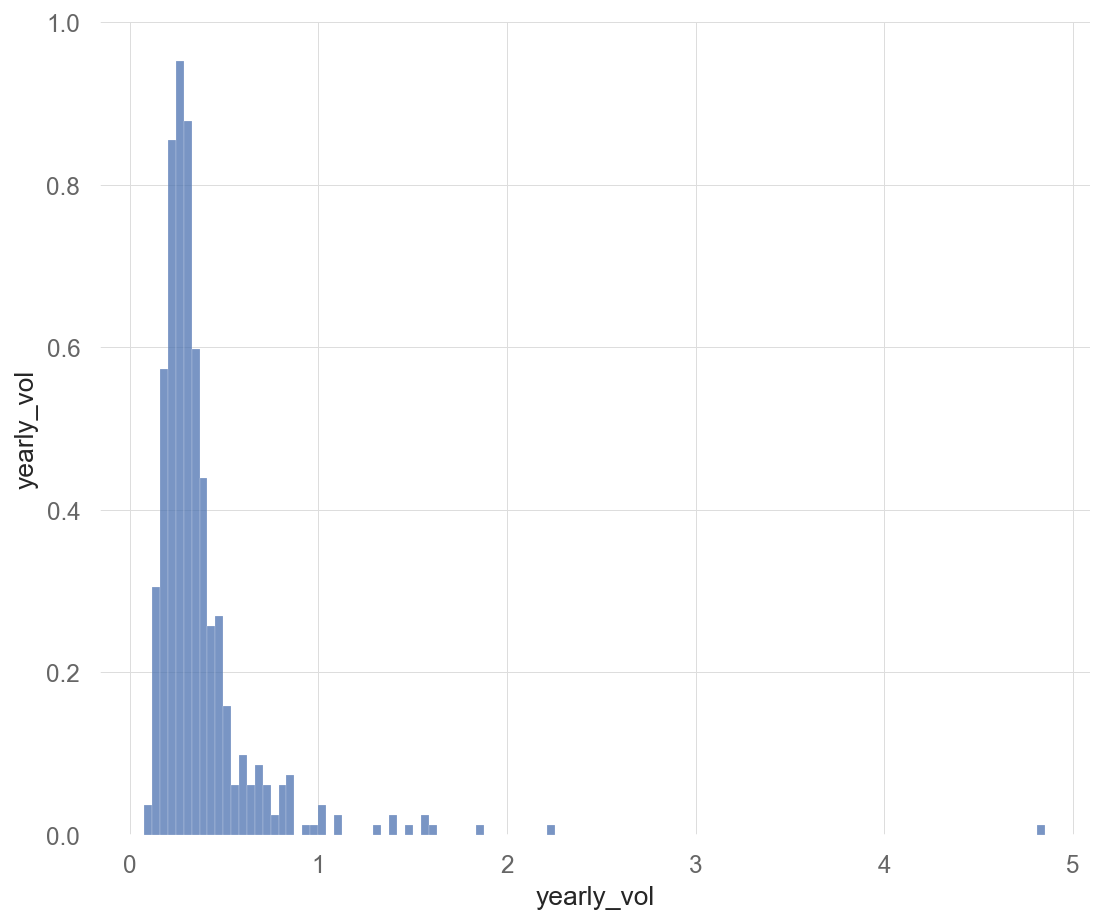

In [39]:
g=sns.pairplot(X)
g.fig.set_size_inches(10,8)
plt.show()

In [ ]:
### Remove Outliers 

In [40]:
np.where(X_scaled['yearly_vol'] == np.max(X_scaled['yearly_vol']))[0]

array([378])

In [41]:
X_scaled.index[378]

'QCOM'

In [42]:
X = X.drop(X_scaled.index[378])

In [43]:
X_scaled = X_scaled[X_scaled['yearly_vol']<np.max(X_scaled['yearly_vol'])]

### Hierarchical Agglomerative Clustering


In [44]:
import scipy.stats as stats
from sklearn import cluster, metrics
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet, fcluster
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_samples, silhouette_score

In [45]:
hier_comp = linkage(X_scaled, method='complete', metric='euclidean')
hier_average = linkage(X_scaled, method='average', metric='euclidean')
hier_ward = linkage(X_scaled, method='ward', metric='euclidean')


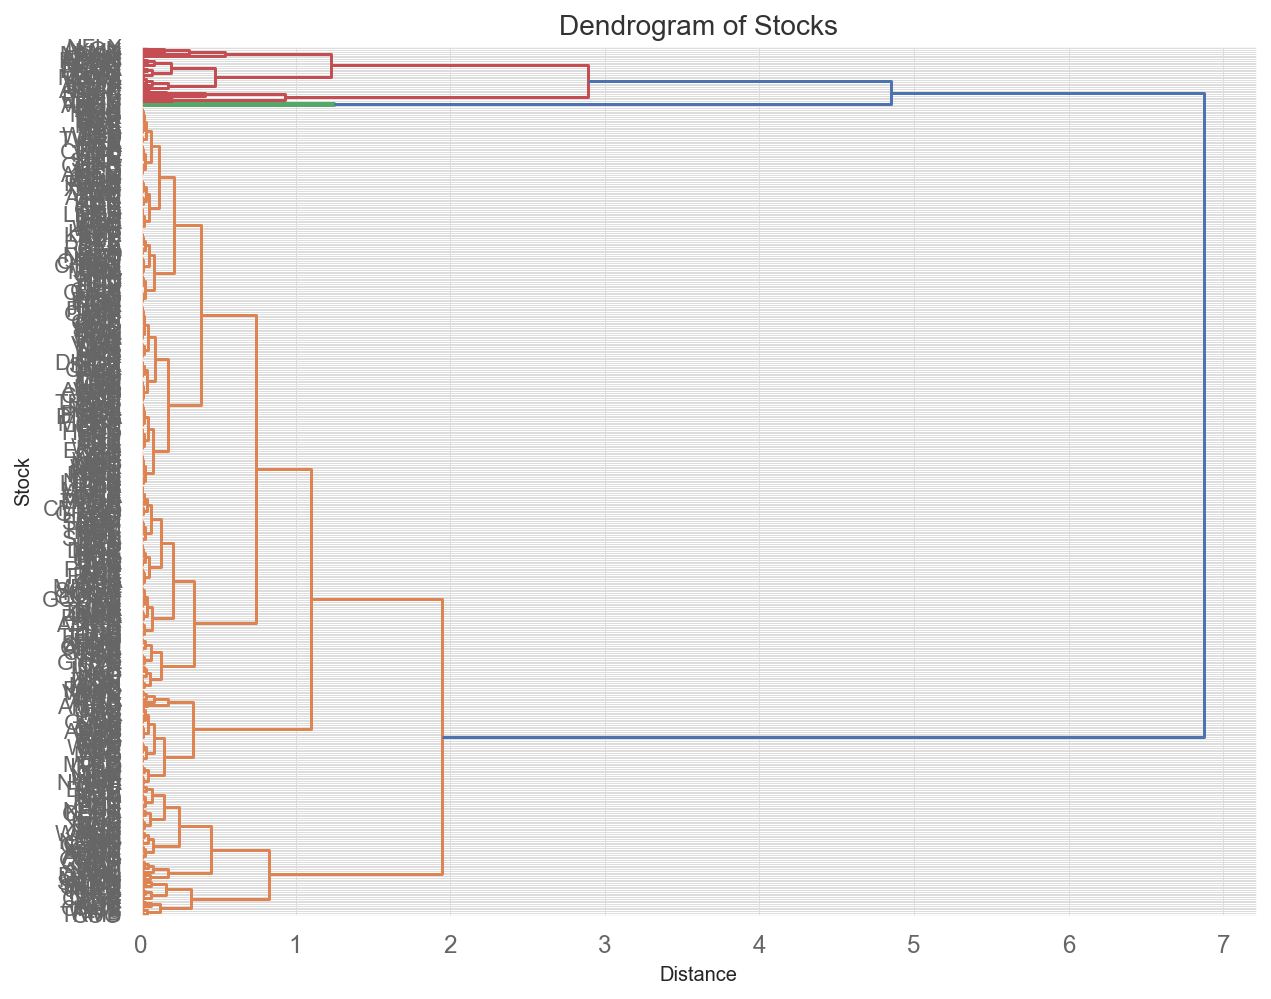

In [46]:
plt.figure(figsize=(10, 8))
plt.title('Dendrogram of Stocks', fontsize=14)
plt.xlabel('Distance', fontsize=10)
plt.ylabel('Stock', fontsize=10)
dendrogram(
    hier_comp,
    orientation='right',
    #     leaf_rotation=90.,
    leaf_font_size=20,
    labels=X_scaled.index.values,
    color_threshold=3
)
plt.yticks(fontsize=11)
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
plt.title('Dendrogram (Average)', fontsize=14)
plt.xlabel('Distance', fontsize=10)
plt.ylabel('Stock', fontsize=10)
dendrogram(
    hier_average,
    orientation='right',
    #     leaf_rotation=90.,
    leaf_font_size=20,
    labels=X_scaled.index.values,
    color_threshold=2.0
)
plt.yticks(fontsize=11)
plt.show()

In [ ]:
plt.figure(figsize=(10, 8))
plt.title('Dendrogram (Ward)', fontsize=14)
plt.xlabel('Distance', fontsize=10)
plt.ylabel('Stock', fontsize=10)
dendrogram(
    hier_ward,
    orientation='right',
    #     leaf_rotation=90.,
    leaf_font_size=20,
    labels=X_scaled.index.values,
    color_threshold=5
)
plt.yticks(fontsize=11)
plt.show()

In [ ]:
hier_comp = linkage(X_scaled, method='complete', metric='euclidean')
c, coph_dists = cophenet(hier_comp, pdist(X, metric='euclidean'))
c

In [ ]:
hier_average = linkage(X_scaled, method='average', metric='euclidean')
c, coph_dists = cophenet(hier_average, pdist(X, metric='euclidean'))
c

In [ ]:
hier_ward = linkage(X_scaled, method='ward', metric='euclidean')
c, coph_dists = cophenet(hier_ward, pdist(X, metric='euclidean'))
c

### Evalutation 

In [ ]:
scores_complete = []
for k in range(2, 4):
    model = AgglomerativeClustering(n_clusters=k, affinity='euclidean', linkage='complete')  
    q = model.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, q, metric='euclidean')
    d = {'k':[k], 's': [s]}
    temp = pd.DataFrame(data=d)
    scores_complete.append(temp)
    #print('{} number of clusters has Silhouette score of {:0.6f}'.format(k, s))


In [ ]:
scores_complete =pd.concat(scores_complete)
scores_complete[scores_complete.s == max(scores_complete.s)]

In [ ]:
# Same when we use Average linkage
scores_average = []
for k in range(2, 4):
    model = AgglomerativeClustering(n_clusters=k, affinity='euclidean', linkage='average')  
    q = model.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, q, metric='euclidean')
    d = {'k':[k], 's': [s]}
    temp = pd.DataFrame(data=d)
    scores_average.append(temp)
    #print('{} number of clusters has Silhouette score of {:0.6f}'.format(k, s))

In [ ]:
scores_average =pd.concat(scores_average)
scores_average[scores_average.s == max(scores_average.s)]

In [ ]:
# Slightly different scores for the Ward linkage, due to the difference in results
scores_ward = []
for k in range(2, 4):
    model = AgglomerativeClustering(n_clusters=k, affinity='euclidean', linkage='ward')  
    q = model.fit_predict(X_scaled)
    s = silhouette_score(X_scaled, q, metric='euclidean')
    d = {'k':[k], 's': [s]}
    temp = pd.DataFrame(data=d)
    scores_ward.append(temp)
    #print('{} number of clusters has Silhouette score of {:0.6f}'.format(k, s))

In [ ]:
scores_ward =pd.concat(scores_ward)
scores_ward[scores_ward.s == max(scores_ward.s)]

All suggest 2 volatility clusters 

In [ ]:
# So we set the AH algorithm with Complete linkage and 4 clusters 
cluster_comp = AgglomerativeClustering(n_clusters=2, affinity='euclidean', linkage='ward')  

In [ ]:
X['clusters'] = cluster_comp.fit_predict(X_scaled)
X

In [ ]:
X[X.clusters == 0].mean()

In [ ]:
X[X.clusters == 1].mean()

So, High - Low volatility stocks 

To do:

    - Automate the process (check sensitivity to outliers) 
    - Check other features (betas, returns etc .. )  
    - look sensitivity to the yield curve (shift - slope - curvature factors) or other macro variables 
    - Check clustering of currencies  
    